In [2]:
import numpy as np
import os
from tensorflow import keras
from tensorflow.keras import layers, optimizers
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib.ticker import (MultipleLocator,FormatStrFormatter)

In [3]:
trainData = pd.read_csv("mnist_train.zip")
testData = pd.read_csv("mnist_test.zip")
Xtrain , Ytrain = trainData.iloc[:,1:].to_numpy(),trainData.iloc[:,0].to_numpy()
Xtest , Ytest = testData.iloc[:,1:].to_numpy(),testData.iloc[:,0].to_numpy()

In [4]:
trainData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59999 entries, 0 to 59998
Columns: 785 entries, 5 to 0.617
dtypes: int64(785)
memory usage: 359.3 MB


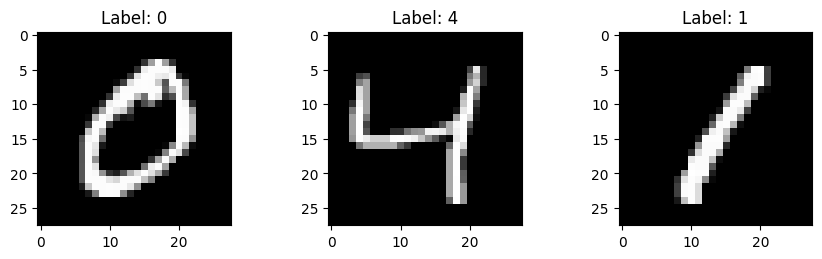

In [5]:
plt.figure(figsize=(10,10))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(Xtrain[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {Ytrain[i]}")
    plt.axis(True)
    plt.subplots_adjust(wspace=0.5,hspace=0.5)

In [6]:
Xtrain = Xtrain.astype('float32')/255.0
Xtest = Xtest.astype('float32')/255.0

In [7]:
Ytrain = keras.utils.to_categorical(Ytrain, num_classes=10)
Ytest = keras.utils.to_categorical(Ytest, num_classes=10)

In [8]:
Ytrain[1]

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

In [9]:
model = keras.Sequential([
    keras.layers.Input(shape=(Xtrain.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")])

In [11]:
history = model.fit(Xtrain, Ytrain,
                    validation_split=0.15,
                    batch_size=128,
                    epochs=20,
                    shuffle=True)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9029 - loss: 0.3508 - val_accuracy: 0.9509 - val_loss: 0.1641
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9584 - loss: 0.1387 - val_accuracy: 0.9672 - val_loss: 0.1137
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9709 - loss: 0.0949 - val_accuracy: 0.9733 - val_loss: 0.0916
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9789 - loss: 0.0710 - val_accuracy: 0.9727 - val_loss: 0.0903
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9827 - loss: 0.0563 - val_accuracy: 0.9760 - val_loss: 0.0830
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9861 - loss: 0.0442 - val_accuracy: 0.9767 - val_loss: 0.0803
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9885 - loss: 0.0379 - val_accuracy: 0.9760 - val_loss: 0.0850
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9910 - loss: 0.0288 - val_accuracy: 0.

In [12]:
def plot_results(history):
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    
    # Plot loss
    ax[0].plot(history.history['loss'], label='Training Loss')
    ax[0].plot(history.history['val_loss'], label='Validation Loss')
    ax[0].set_title('Loss over Epochs')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True)
    
    # Plot accuracy
    ax[1].plot(history.history['accuracy'], label='Training Accuracy')
    ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax[1].set_title('Accuracy over Epochs')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    ax[1].grid(True)
    
    plt.show()

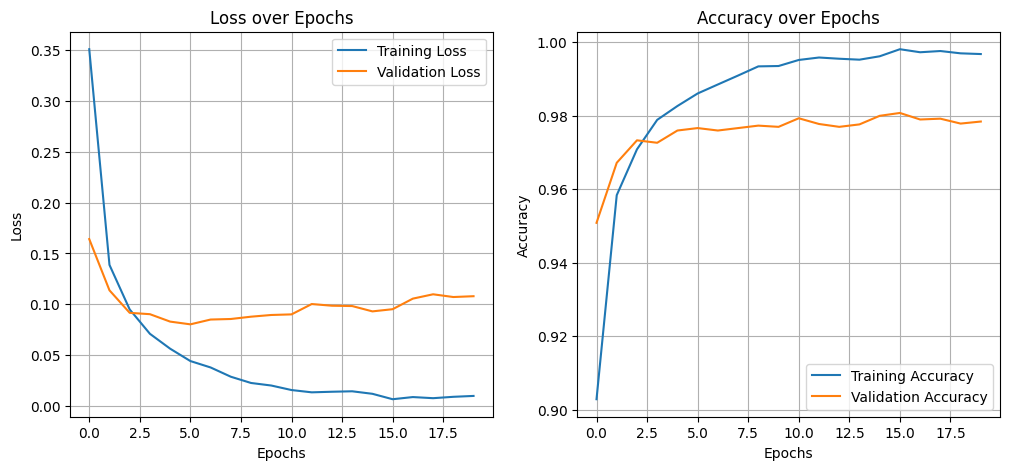

In [13]:
plot_results(history)

In [14]:
Ypred = model.predict(Xtest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [15]:
print("Predicted labels: ", np.argmax(Ypred, axis=1)[:10])
print("True labels:      ", np.argmax(Ytest, axis=1)[:10])

Predicted labels:  [2 1 0 4 1 4 9 5 9 0]
True labels:       [2 1 0 4 1 4 9 5 9 0]


In [16]:
print(Ytest[0])
print(Ypred[0])

[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[4.93885735e-14 1.58004013e-07 9.99999881e-01 1.92010241e-10
 1.89223734e-23 3.93387512e-15 6.90156645e-13 1.34804817e-20
 1.21778365e-08 3.01770976e-18]


In [21]:
# Ensure labels are integer class indices (NOT one-hot)
# This prevents shape mismatch when using sparse_categorical_crossentropy.
if hasattr(Ytrain, "ndim") and Ytrain.ndim == 2 and Ytrain.shape[1] == 10:
    Ytrain = np.argmax(Ytrain, axis=1)
if hasattr(Ytest, "ndim") and Ytest.ndim == 2 and Ytest.shape[1] == 10:
    Ytest = np.argmax(Ytest, axis=1)

Ytrain = Ytrain.astype("int64")
Ytest  = Ytest.astype("int64")

In [22]:
def build_model(lr):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model



Training config: batch_size=32, learning_rate=0.0001
Test Accuracy = 0.9576


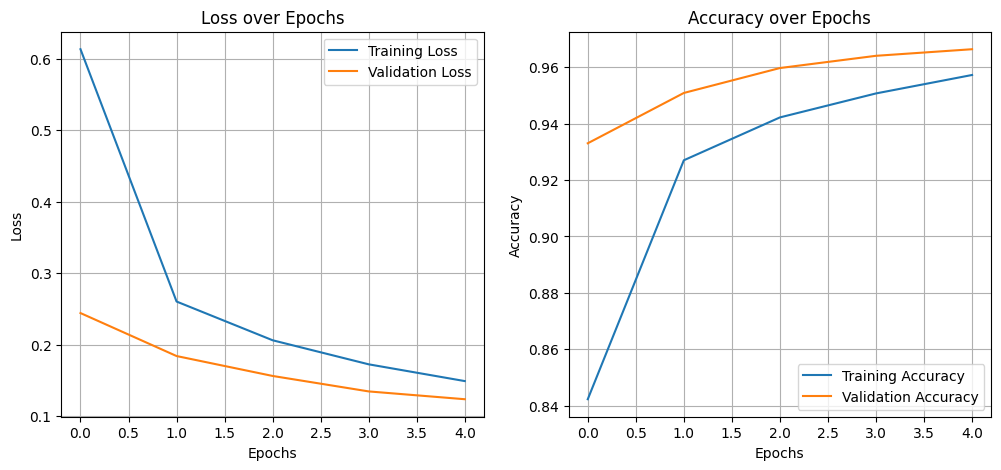


Training config: batch_size=32, learning_rate=0.001
Test Accuracy = 0.9782


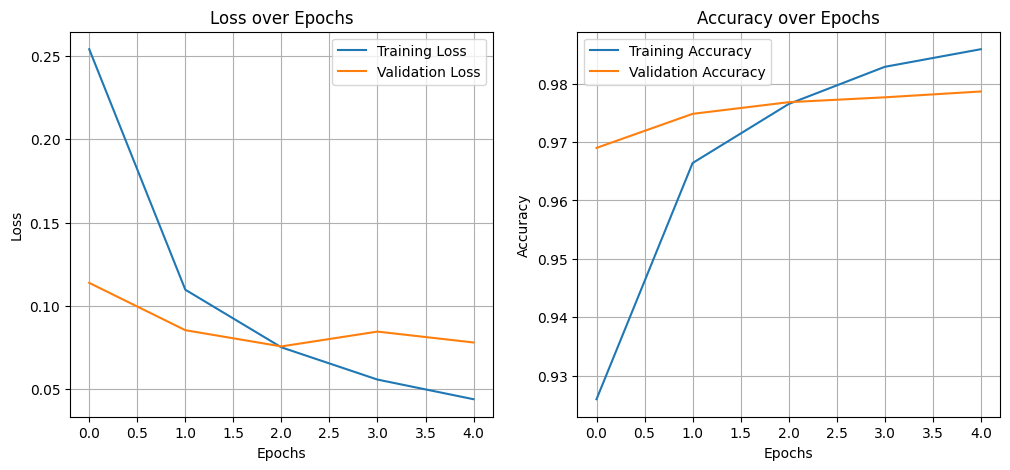


Training config: batch_size=32, learning_rate=0.01
Test Accuracy = 0.9579


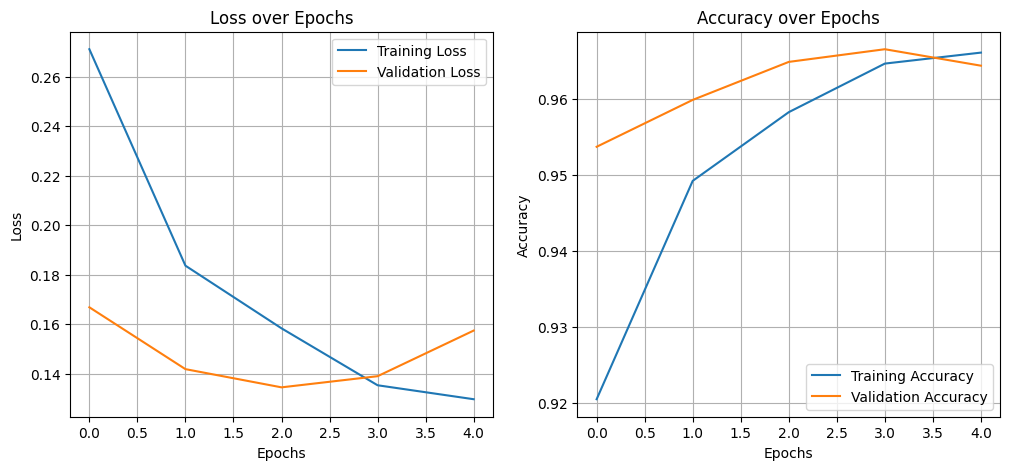


Training config: batch_size=128, learning_rate=0.0001
Test Accuracy = 0.9420


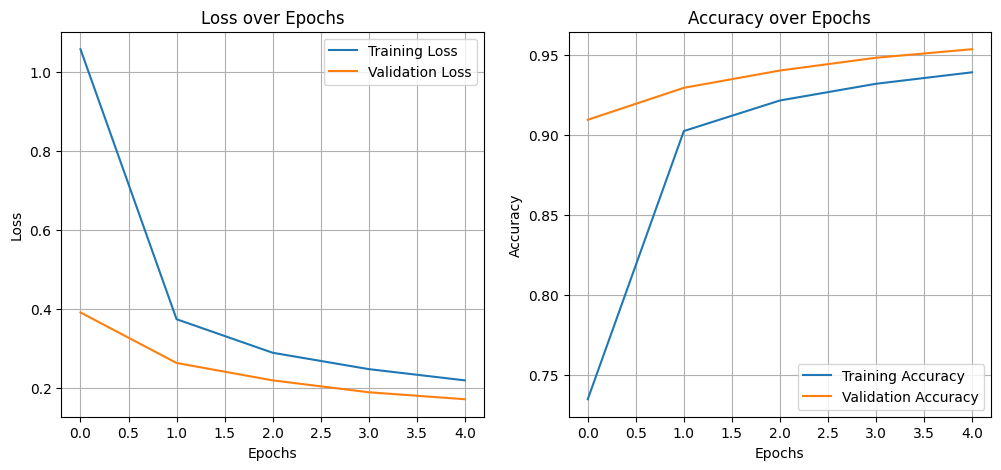


Training config: batch_size=128, learning_rate=0.001
Test Accuracy = 0.9742


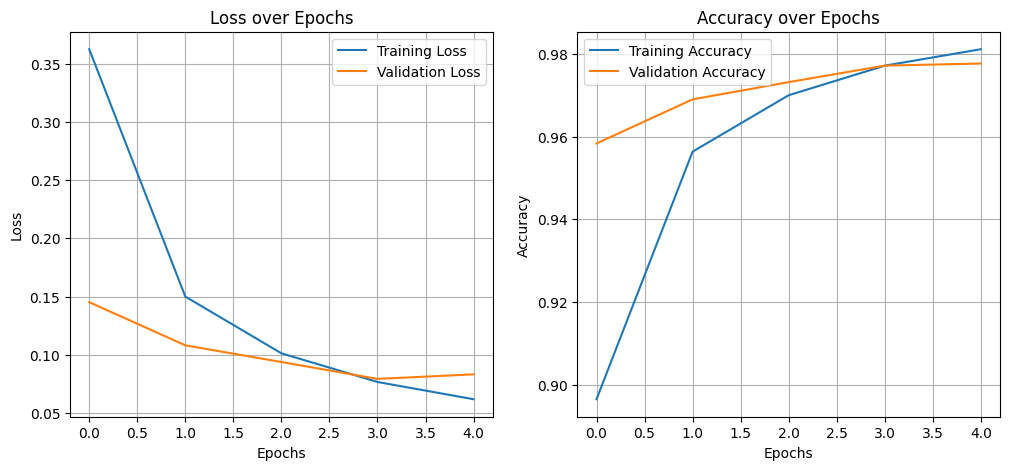


Training config: batch_size=128, learning_rate=0.01
Test Accuracy = 0.9657


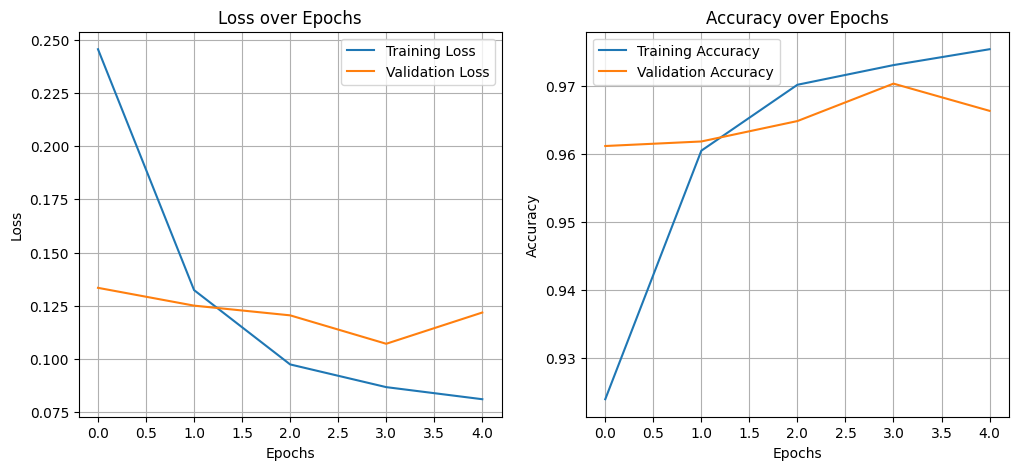


Training config: batch_size=512, learning_rate=0.0001
Test Accuracy = 0.9196


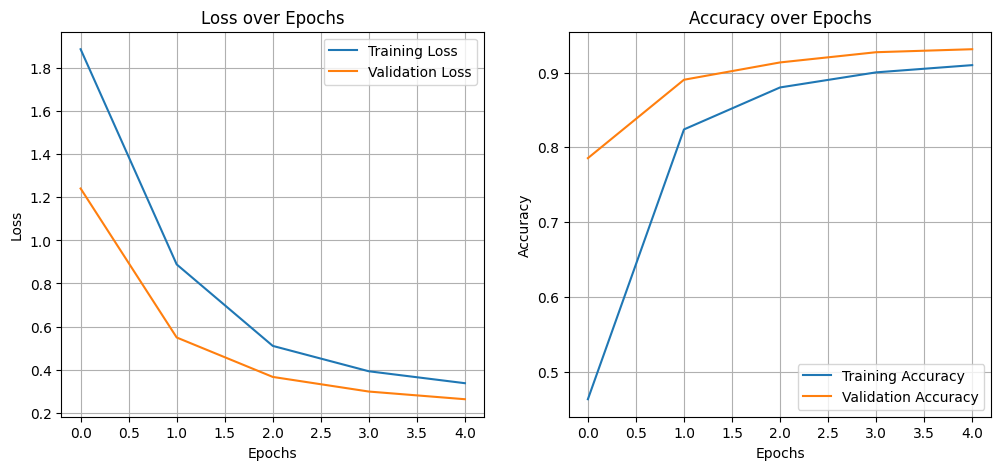


Training config: batch_size=512, learning_rate=0.001
Test Accuracy = 0.9619


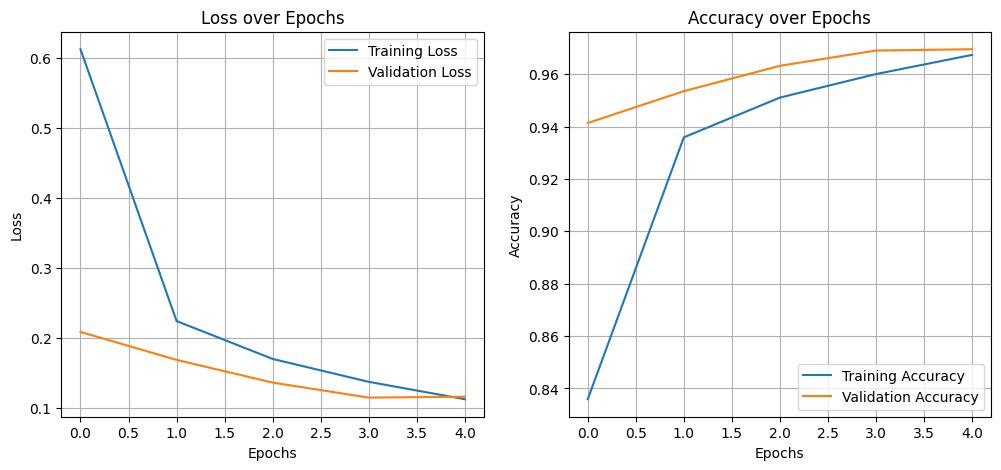


Training config: batch_size=512, learning_rate=0.01
Test Accuracy = 0.9726


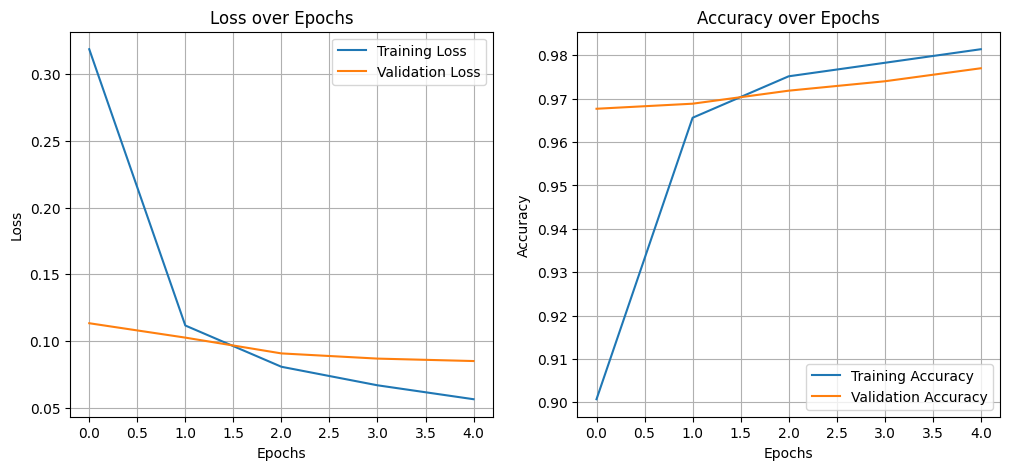


Summary (sorted by Test Accuracy):
batch_size= 32, lr=0.001  -> test_acc=0.9782
batch_size=128, lr=0.001  -> test_acc=0.9742
batch_size=512, lr=0.01   -> test_acc=0.9726
batch_size=128, lr=0.01   -> test_acc=0.9657
batch_size=512, lr=0.001  -> test_acc=0.9619
batch_size= 32, lr=0.01   -> test_acc=0.9579
batch_size= 32, lr=0.0001 -> test_acc=0.9576
batch_size=128, lr=0.0001 -> test_acc=0.9420
batch_size=512, lr=0.0001 -> test_acc=0.9196


In [25]:
batch_sizes = [32, 128, 512]
learning_rates = [1e-4, 1e-3, 1e-2]
results = {}
histories = {}
for bs in batch_sizes:
    for lr in learning_rates:
        print("\n" + "="*70)
        print(f"Training config: batch_size={bs}, learning_rate={lr}")
        print("="*70)

        model = build_model(lr)
        history = model.fit(
            Xtrain, Ytrain,
            epochs=5,
            batch_size=bs,
            validation_split=0.1,
            verbose=0
        )

        histories[(bs, lr)] = history
        test_loss, test_acc = model.evaluate(Xtest, Ytest, verbose=0)
        results[(bs, lr)] = test_acc
        print(f"Test Accuracy = {test_acc:.4f}")

        plot_results(history)

print("\nSummary (sorted by Test Accuracy):")
for (bs, lr), acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"batch_size={bs:>3}, lr={lr:<6} -> test_acc={acc:.4f}")

## Conclusions

### Batch Size
Smaller batch sizes provide better generalization at the cost of slower convergence.

### Learning Rate
A learning rate of 1e-3 provides the best balance between stability and speed.

### Label Representation
Using class indices with sparse categorical cross-entropy simplifies training without loss of accuracy.